# Tutorial: `context_v3` initialization from raw data

This notebook presents a short, tutorial-style workflow focused only on the initialization step.

It shows how to:
- initialize a `WorkflowContext` from a raw-data directory using `context_v3`,
- inspect detected runs and configurations,
- inspect the dedicated reference stores filled during initialization,
- review warnings and basic sanity checks.

The idea is to keep the notebook focused on a single stage: **load and inspect**.


## 1. Environment setup

This first cell moves the notebook to the repository root and adds `src/` to the `PYTHONPATH`.
This is useful whether the notebook is launched from `notebooks/` or from the repository root.


In [1]:
from pathlib import Path
import os
import sys

%matplotlib inline

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Repository root: {ROOT}")
print(f"Python path includes: {SRC}")


Repository root: /home/achennev/python/scarlet
Python path includes: /home/achennev/python/scarlet/src


## 2. Define the working paths

Here we define:
- the raw-data directory,
- the output directory used for converted files,
- the instrument name passed to the raw-data converter.


In [2]:
from scarlet.workflow.context import initialize_workflow_context_from_raw_directory, WorkflowContext

RAW_DIR = ROOT / "data" / "SANSLLB" / "raw_june"
OUTPUT_DIR = ROOT / "data" / "SANSLLB" / "out_june_v3"
INSTRUMENT_NAME = "sansllb"

RAW_DIR, OUTPUT_DIR


(PosixPath('/home/achennev/python/scarlet/data/SANSLLB/raw_june'),
 PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3'))

## 3. Initialize the `WorkflowContext`

This step scans the raw files, converts them to the SCARLET raw format,
detects runs, builds instrumental configurations, and stores everything in a `WorkflowContext` object.


In [3]:
w = initialize_workflow_context_from_raw_directory(
    RAW_DIR,
    instrument_name=INSTRUMENT_NAME,
    output_dir=OUTPUT_DIR,
    overwrite=True,
)

print(f"runs: {len(w.runs)}")
print(f"configurations: {len(w.configurations)}")
print(f"issues: {len(w.issues)}")
print(f"artifacts: {len(w.artifacts)}")
print(f"output_dir: {w.output_dir}")


runs: 200
configurations: 21
issues: 158
artifacts: 200
output_dir: /home/achennev/python/scarlet/data/SANSLLB/out_june_v3


## 7. Review initialization issues

Warnings collected during initialization are often useful when tuning the automatic classification.


In [4]:
# issue_rows = [
#     {
#         "level": issue.level,
#         "where": issue.where,
#         "key": issue.key,
#         "message": issue.message,
#     }
#     for issue in w.issues
# ]

# issue_rows[:20]


In [5]:
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
H2O,config_1,scattering,water,1,,sans-llb2026n000902.nxs
H2O,config_2,scattering,water,1,,sans-llb2026n000903.nxs
H2O,config_3,scattering,water,1,,sans-llb2026n000904.nxs
H2O,config_4,scattering,water,1,,sans-llb2026n000905.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000908.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000909.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000910.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000911.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000912.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000913.nxs


In [6]:
w.write_runs_table_csv('runs_v3.csv',overwrite=True)

PosixPath('/home/achennev/python/scarlet/runs_v3.csv')

In [7]:
w.update_from_runs_table_csv("/home/achennev/python/scarlet/data/SANSLLB/raw/runs_v3_filtered.csv")
w.compute_transmissions()
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
Cd,config_9,transmission,dark,,,sans-llb2026n000974.nxs
EB,config_9,transmission,empty_beam,,,sans-llb2026n000975.nxs
AgBe,config_9,transmission,sample,1,0.744027,sans-llb2026n000976.nxs
EC,config_9,transmission,empty_cell,,0.868319,sans-llb2026n000977.nxs
H2O,config_9,transmission,water,1,,sans-llb2026n000978.nxs
ludox_AM20,config_9,transmission,sample,1,0.53595,sans-llb2026n000979.nxs
ludox_SM30,config_9,transmission,sample,1,0.555082,sans-llb2026n000980.nxs
ludox_TM50,config_9,transmission,sample,1,0.570916,sans-llb2026n000981.nxs
Cd,config_9,scattering,dark,,,sans-llb2026n000982.nxs
EB,config_9,scattering,empty_beam,,,sans-llb2026n000983.nxs


In [8]:
w.configurations_table()

config_id,wavelength,sample_detector_distance,collimation_distance,last_aperture_to_sample_distance,aperture1,aperture2,notes
config_10,5.00051 A,detector0=2 m; detector1=0.809993 m; detector2=0.809993 m,0.5 m,1.6 m,slit x=0.0499996 m y=0.05 m,slit x=0.0254997 m y=0.0254998 m,
config_9,4.99971 A,detector0=8.00001 m; detector1=2.66667 m; detector2=2.66667 m,1.33333 m,1.6 m,slit x=0.0237499 m y=0.0237499 m,slit x=0.0145619 m y=0.0145621 m,


In [9]:
w.attach_mask_bundles_from_output_dir()
w.mask_files

{'config_9': PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/mask_8m_viewer.nxs'),
 'config_10': PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/masks_2m_viewer.nxs')}

In [10]:
w.build_water_flatfield(config_id="config_10")
w.set_flatfield_source(config_id="config_9", source_config_id="config_10")

'config_10'

## Test Pipepline

In [11]:
from scarlet.workflow.pipeline import ReductionPipeline, ReductionState

state = ReductionState(sample_name="ludox_SM30",config_id="config_9", workflow=w)
state2 = ReductionState(sample_name="ludox_SM30",config_id="config_10", workflow=w) 
pipe = ReductionPipeline().with_azimuthal_averaging()
pipe.run(state)
pipe.run(state2)


ReductionState(sample_name='ludox_SM30', config_id='config_10', workflow=WorkflowContext(experiment_id='experiment', instrument_name='sansllb', root_dir=PosixPath('/home/achennev/python/scarlet/data/SANSLLB/raw_june'), output_dir=PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3'), runs={RunKey(config_id='config_9', entity='dark', mode='transmission', sample_name='Cd'): PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n000974.nxs'), RunKey(config_id='config_9', entity='empty_beam', mode='transmission', sample_name='EB'): PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n000975.nxs'), RunKey(config_id='config_9', entity='sample', mode='transmission', sample_name='AgBe'): PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n000976.nxs'), RunKey(config_id='config_9', entity='empty_cell', mode='transmission', sample_name='EC'): PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v

/home/achennev/python/scarlet/.venv/lib/python3.12/site-packages/plopp/plotting/common.py:302: RuntimeWarning: The input contains a coordinate with unsorted values (q). The results may be unpredictable. Coordinates can be sorted using `scipp.sort(data, dim="to_be_sorted", order="ascending")`.
  _check_coord_sanity(out)


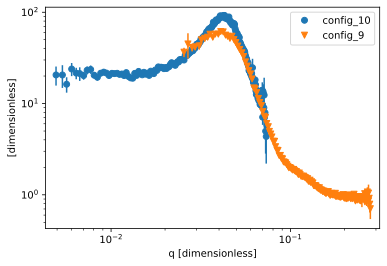

In [12]:
import plopp as pp

pp.plot({"config_10":state.detectors[0]*8, "config_9":state2.detectors[0]}, logx=True, logy=True)

In [13]:
w.beam_centers

{'config_10': {0: (62.94175880965219, 62.985789409765225),
  1: (27.67025619822763, 97.74597527073527),
  2: (78.2702593530882, 26.085580854011223)},
 'config_9': {0: (61.722766241269206, 60.11471024943615),
  1: (25.915364503964575, 102.44117647058822),
  2: (73.29049609830884, 24.430970149253746)}}

In [14]:
state.transmission

0.555082004629104

In [15]:
from scarlet.workflow.pipeline import ReductionPipeline, ReductionState

state = ReductionState(sample_name="ludox_SM30",config_id="config_9", workflow=w)
state2 = ReductionState(sample_name="ludox_SM30",config_id="config_10", workflow=w) 
pipe = ReductionPipeline().with_processed_output()
pipe.run(state)
pipe.run(state2)
print(state2.file_path)


/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n001004.nxs


In [ ]:
pipeline = ReductionPipeline.with_azimuthal_text_output()
for run in w.runs:
    if run.entity=="sample" and run.mode=="scattering":
        state = ReductionState(sample_name=run.sample_name, config_id=run.config_id,workflow=w)
        pipe.run(state)